<a href="https://colab.research.google.com/github/Samonto-Karmaker/ZKP-Polynomial-Vs-IMT/blob/v2-hardened-version/IMT_vs_PEB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from IPython.display import display

sns.set_theme(context='paper', style='whitegrid', font_scale=1.2)

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SCHEME_COLORS = {'IMT': '#1f77b4', 'Polynomial': '#ff7f0e'}
SCHEME_MARKERS = {'IMT': 'o', 'Polynomial': 's'}
SCHEME_DASHES = {'IMT': (1, 0), 'Polynomial': (4, 2)}

# Define common plotting constants
LABEL_FONT = 12
TITLE_FONT = 14
POLY_COLOR = SCHEME_COLORS['Polynomial']
IMT_COLOR = SCHEME_COLORS['IMT']
POLY_MARKER = SCHEME_MARKERS['Polynomial']
IMT_MARKER = SCHEME_MARKERS['IMT']
RUN_STYLES = {1: '-', 2: '--'}

def stats_box(ax, lines, loc='upper right', color='#1f77b4'):
    textstr = '\n'.join(lines)
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=color)
    ax.text(0.05 if 'left' in loc else 0.95, 0.95 if 'upper' in loc else 0.05,
            textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top' if 'upper' in loc else 'bottom',
            horizontalalignment='left' if 'left' in loc else 'right',
            bbox=props)

In [44]:
from pathlib import Path

# ── Output directory for saved graphs ────────────────────────────────────────
GRAPHS_DIR = Path().resolve() / 'graphs'
GRAPHS_DIR.mkdir(exist_ok=True)   # creates the folder automatically

In [45]:
from pathlib import Path

_notebook_dir = Path().resolve()
imt_df  = pd.read_csv(_notebook_dir / 'imt_results.csv')
poly_df = pd.read_csv(_notebook_dir / 'polynomial_results.csv')

for df in [imt_df, poly_df]:
    df['run_id'] = df.groupby('user_count').cumcount() + 1

imt_df['scheme_type']  = 'IMT'
poly_df['scheme_type'] = 'Polynomial'

combined = pd.concat([imt_df, poly_df], ignore_index=True)
num_runs = int(combined['run_id'].max())

print(f"Loaded {len(imt_df)} IMT rows and {len(poly_df)} Polynomial rows.")
print(f"Detected {num_runs} run(s) per scheme.")
print(f"\nColumns: {list(combined.columns)}")
combined.head(6)

Loaded 28 IMT rows and 28 Polynomial rows.
Detected 2 run(s) per scheme.

Columns: ['user_count', 'proof_size_bytes', 'proof_gen_time_ms', 'vk_size_bytes', 'verification_time_ms', 'total_population_time_ms', 'avg_population_time_ms', 'total_structure_storage_bytes', 'run_id', 'scheme_type']


,user_count,proof_size_bytes,proof_gen_time_ms,vk_size_bytes,verification_time_ms,total_population_time_ms,avg_population_time_ms,total_structure_storage_bytes,run_id,scheme_type
0,128,7104,94.51,1888,12.85,398.29,3.1116,22108,1,IMT
1,256,7104,93.54,1888,12.54,802.26,3.1338,43292,1,IMT
2,512,7104,100.29,1888,12.89,1620.44,3.1649,85826,1,IMT
3,1024,7104,98.08,1888,13.26,3230.11,3.1544,171137,1,IMT
4,2048,7104,103.56,1888,13.21,6480.51,3.1643,343026,1,IMT
5,4096,7104,94.71,1888,13.04,12900.78,3.1496,687901,1,IMT


In [46]:
if imt_df is not None:
    # Display the first 5 rows of the DataFrame
    print("First 5 rows of the DataFrame:")
    display(imt_df.head())

First 5 rows of the DataFrame:


,user_count,proof_size_bytes,proof_gen_time_ms,vk_size_bytes,verification_time_ms,total_population_time_ms,avg_population_time_ms,total_structure_storage_bytes,run_id,scheme_type
0,128,7104,94.51,1888,12.85,398.29,3.1116,22108,1,IMT
1,256,7104,93.54,1888,12.54,802.26,3.1338,43292,1,IMT
2,512,7104,100.29,1888,12.89,1620.44,3.1649,85826,1,IMT
3,1024,7104,98.08,1888,13.26,3230.11,3.1544,171137,1,IMT
4,2048,7104,103.56,1888,13.21,6480.51,3.1643,343026,1,IMT


C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\3948531222.py:34: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\3948531222.py:35: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(GRAPHS_DIR / f"run_{run_id}_comparison.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


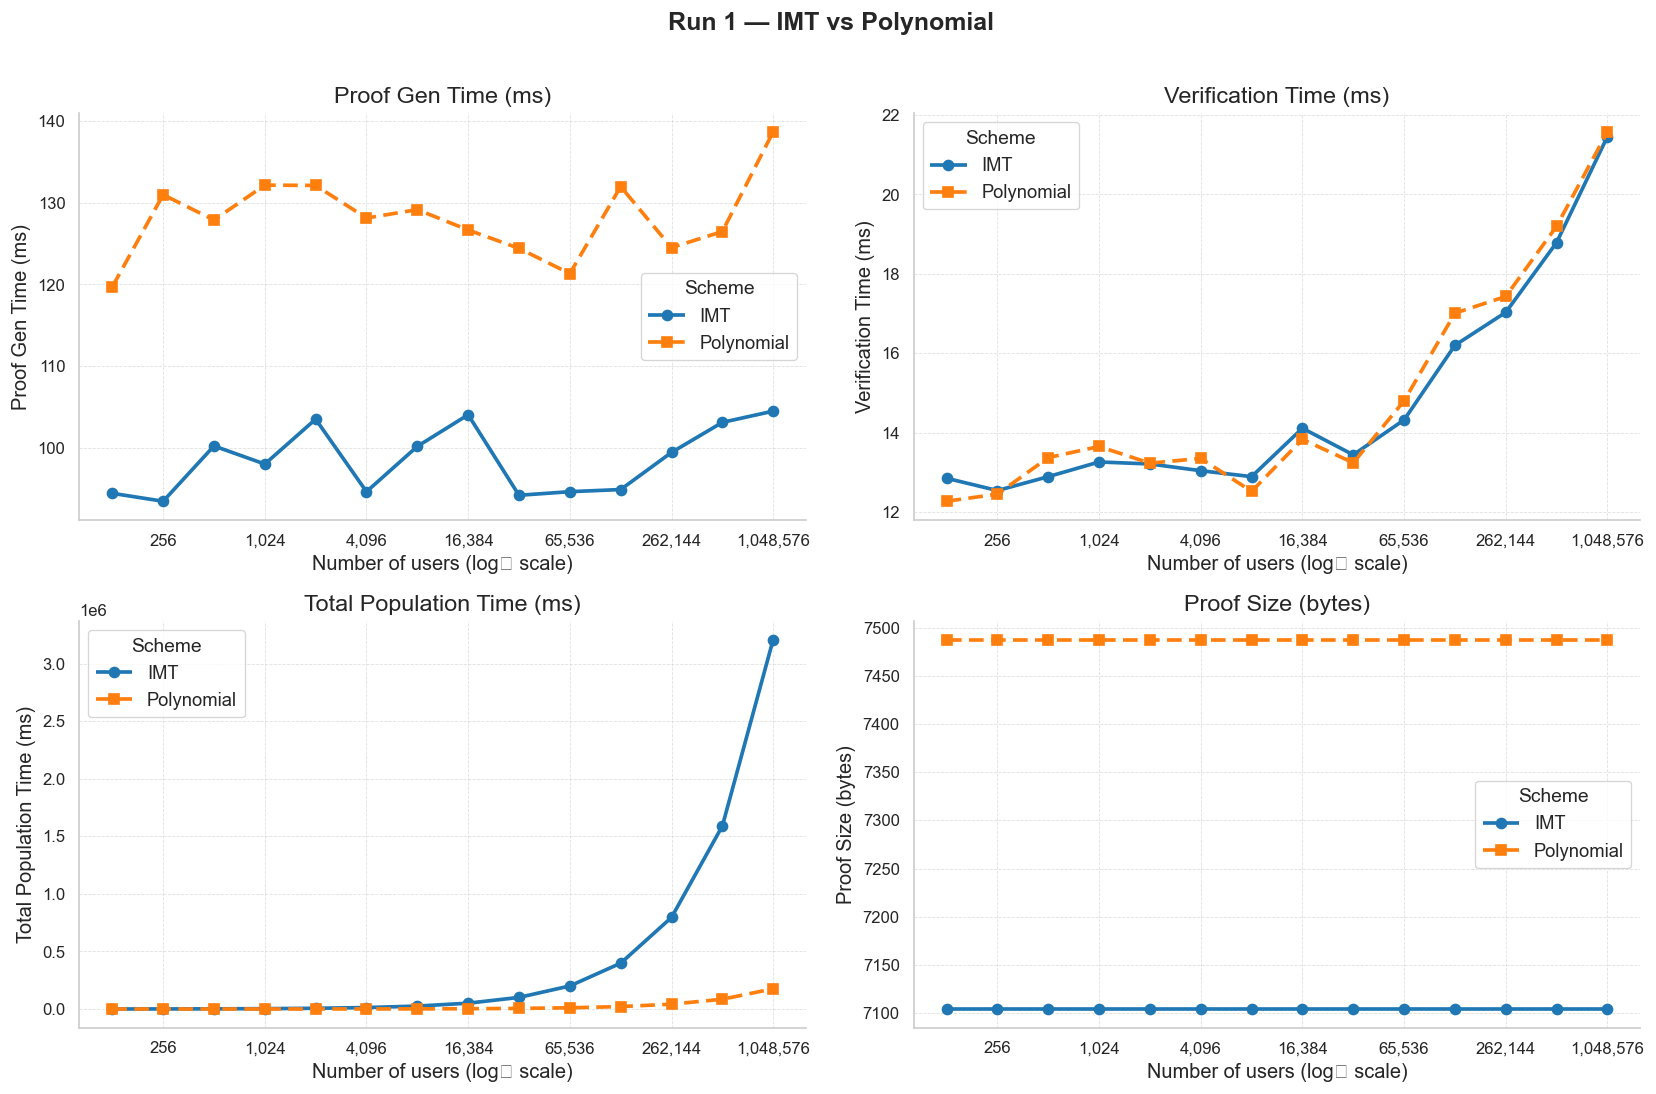

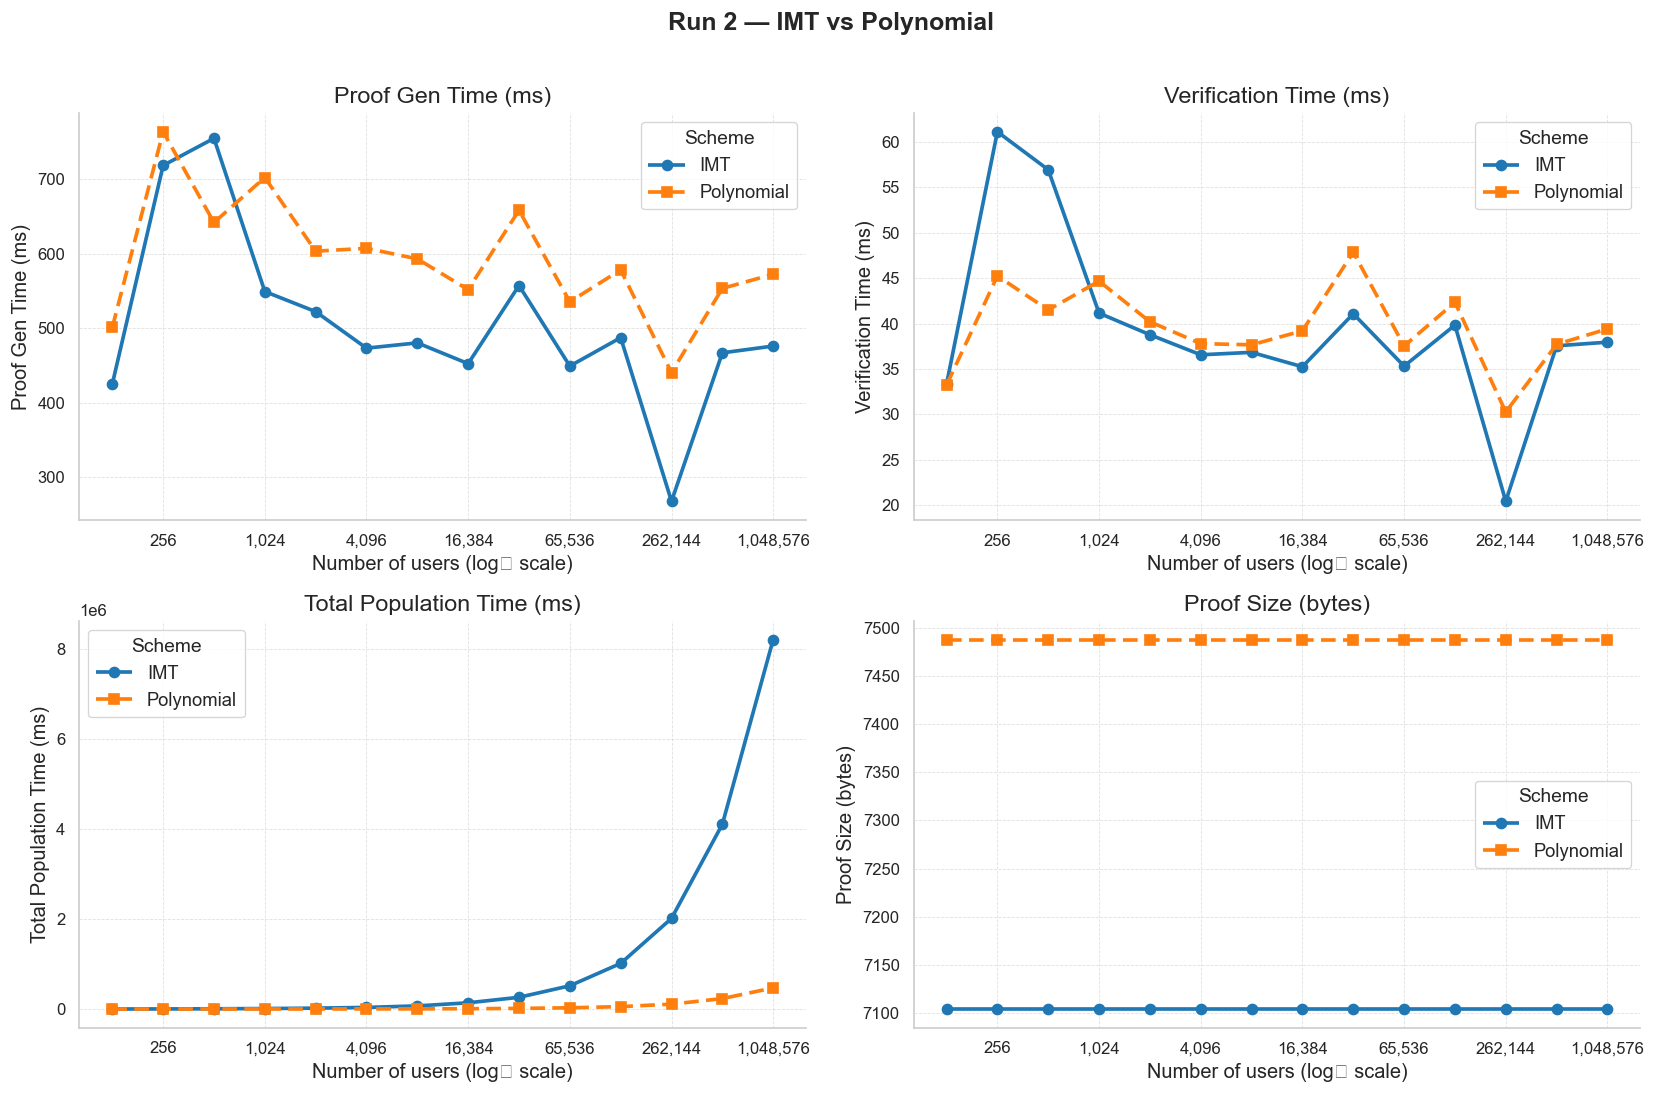

In [47]:
METRICS = [
    ("proof_gen_time_ms",            "Proof Gen Time (ms)"),
    ("verification_time_ms",         "Verification Time (ms)"),
    ("total_population_time_ms",     "Total Population Time (ms)"),
    ("proof_size_bytes",             "Proof Size (bytes)"),
]

def plot_run(df, run_id):
    run_data = df[df['run_id'] == run_id]
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f"Run {run_id} — IMT vs Polynomial", fontsize=15, fontweight='bold', y=1.01)

    for ax, (col, ylabel) in zip(axes.flat, METRICS):
        for scheme, grp in run_data.groupby('scheme_type'):
            grp_sorted = grp.sort_values('user_count')
            ax.plot(
                grp_sorted['user_count'],
                grp_sorted[col],
                label=scheme,
                color=SCHEME_COLORS[scheme],
                marker=SCHEME_MARKERS[scheme],
                dashes=SCHEME_DASHES[scheme],
                linewidth=2.2,
                markersize=6,
            )
        ax.set_xscale('log', base=2)
        ax.set_xlabel("Number of users (log₂ scale)")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend(title="Scheme")
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    plt.tight_layout()
    plt.savefig(GRAPHS_DIR / f"run_{run_id}_comparison.png", bbox_inches='tight')
    plt.show()

for r in range(1, num_runs + 1):
    plot_run(combined, r)


  Individual scheme plots — Run 1

  IMT


C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


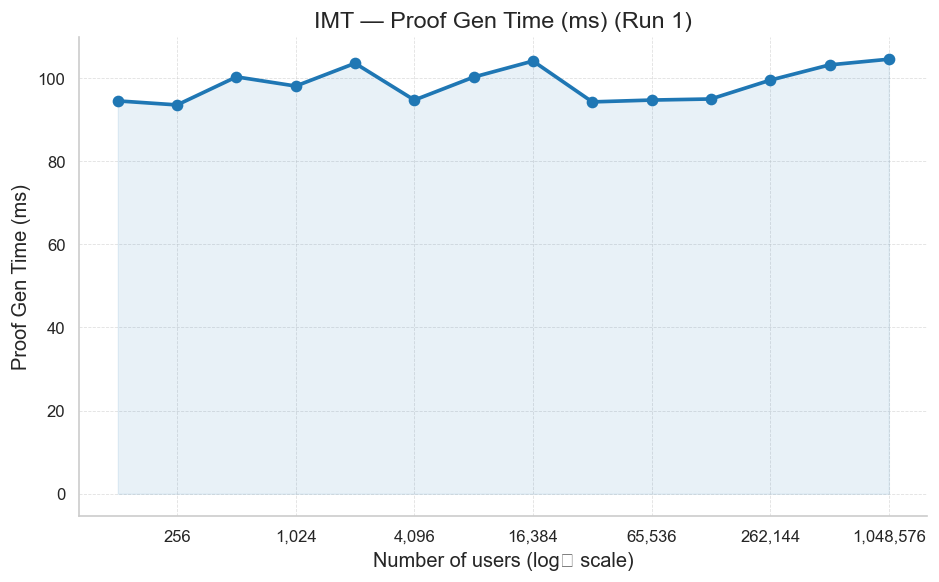

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


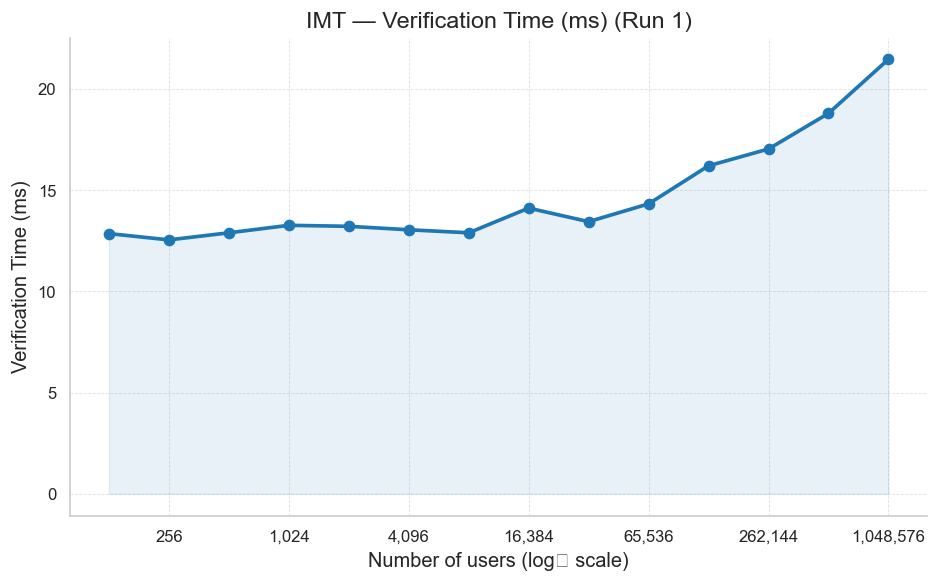

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


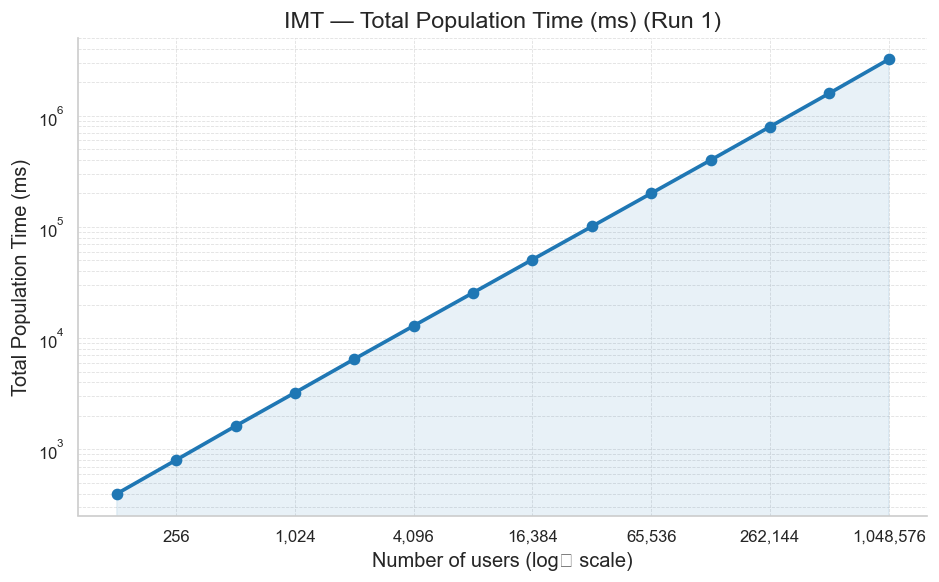

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


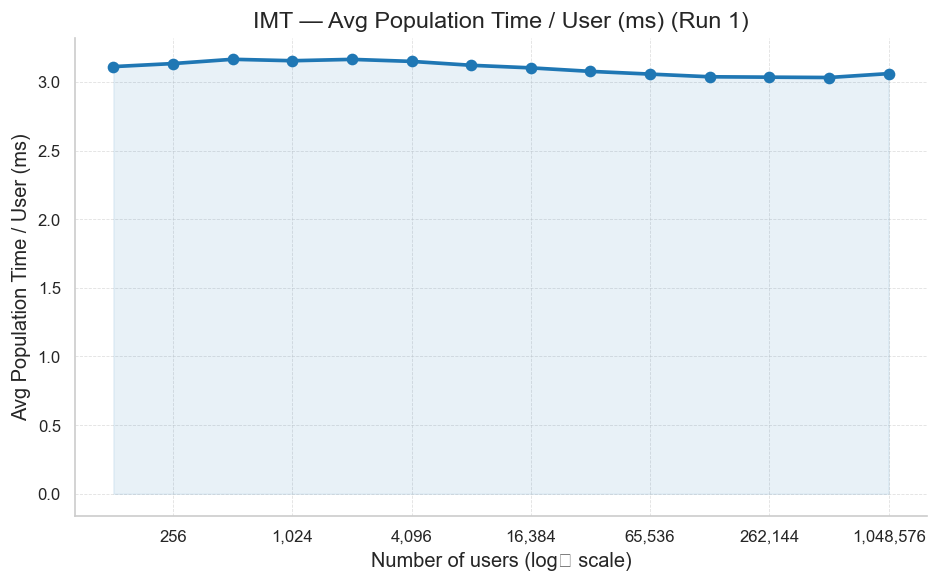

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


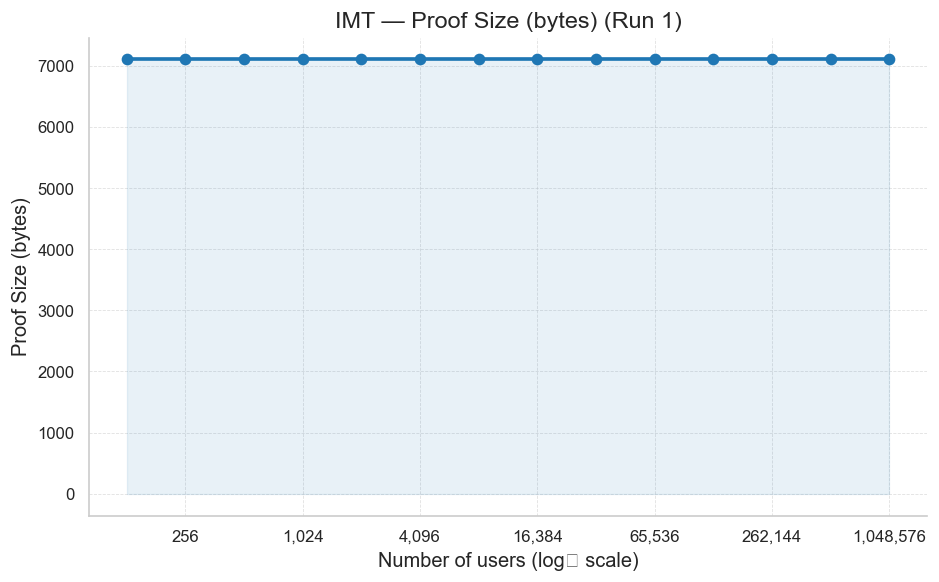

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


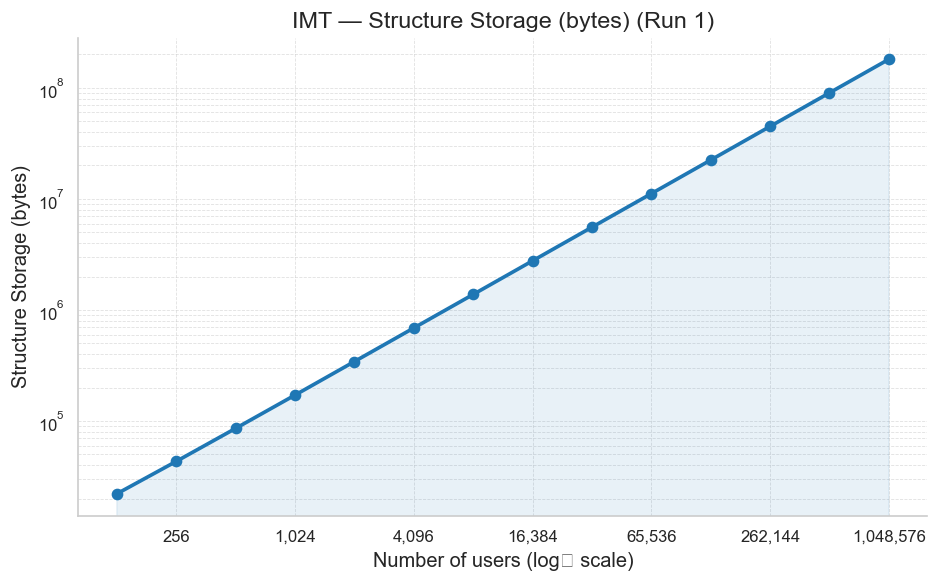


  Polynomial


C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


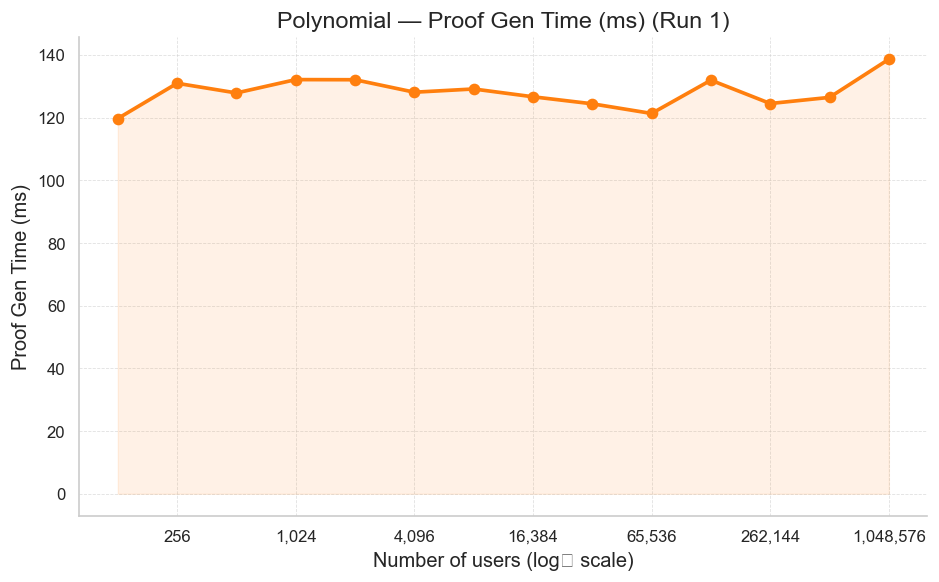

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


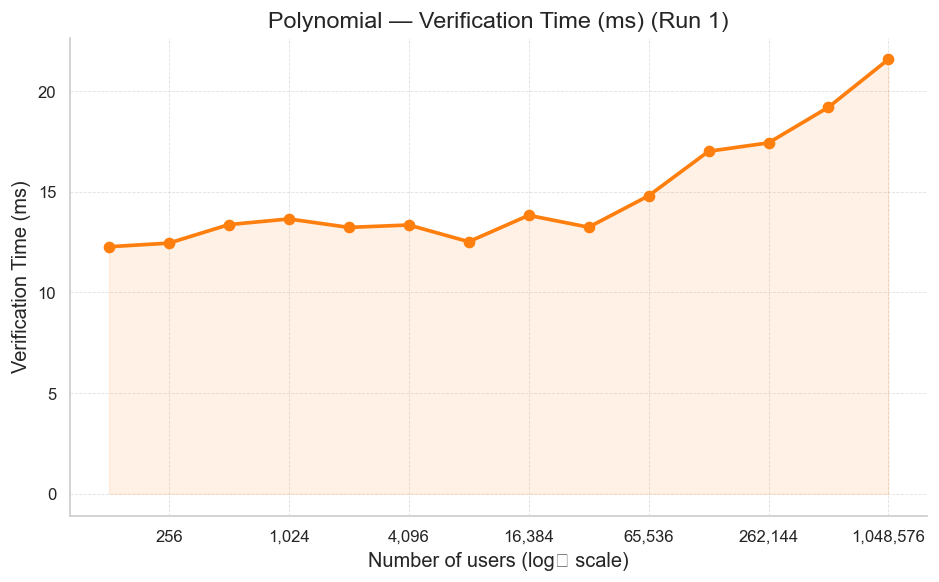

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


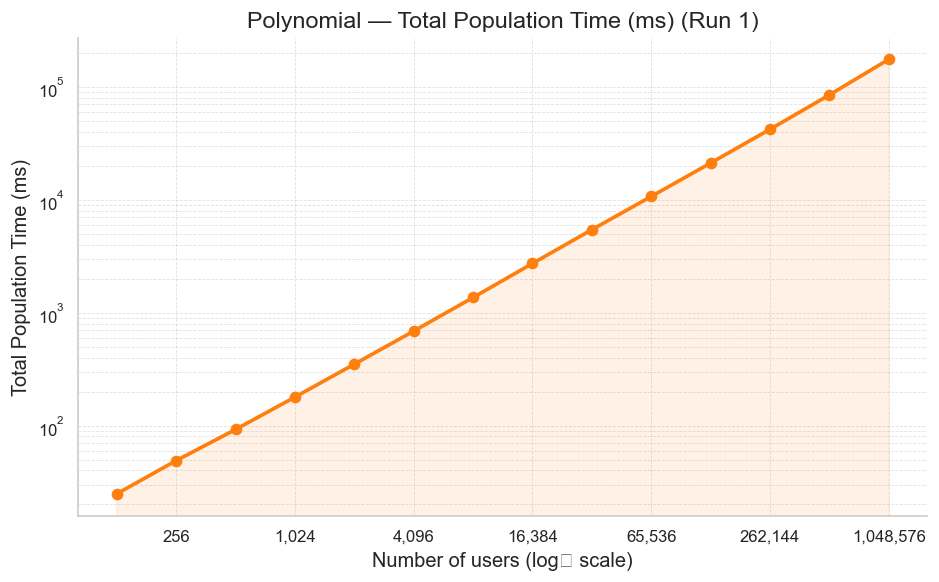

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


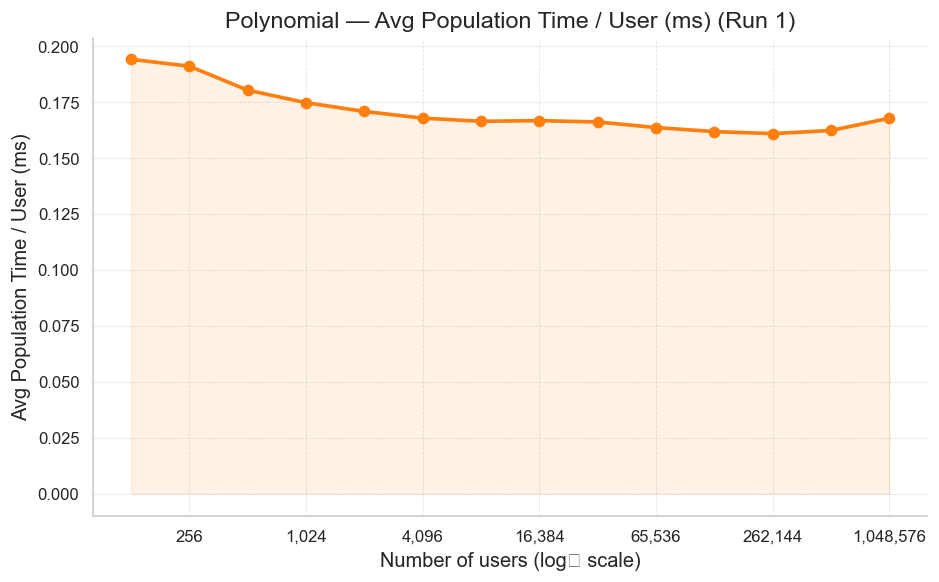

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


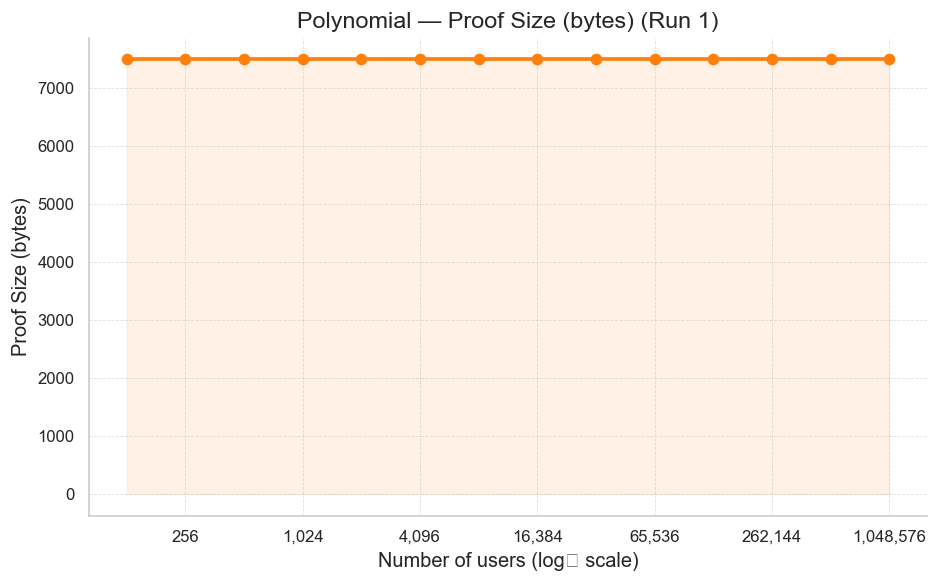

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


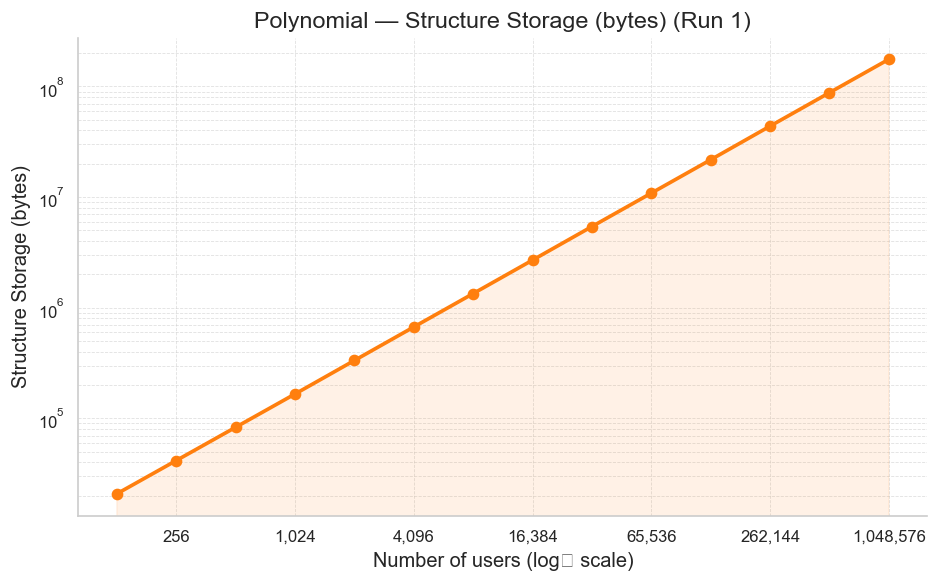


  Individual scheme plots — Run 2

  IMT


C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


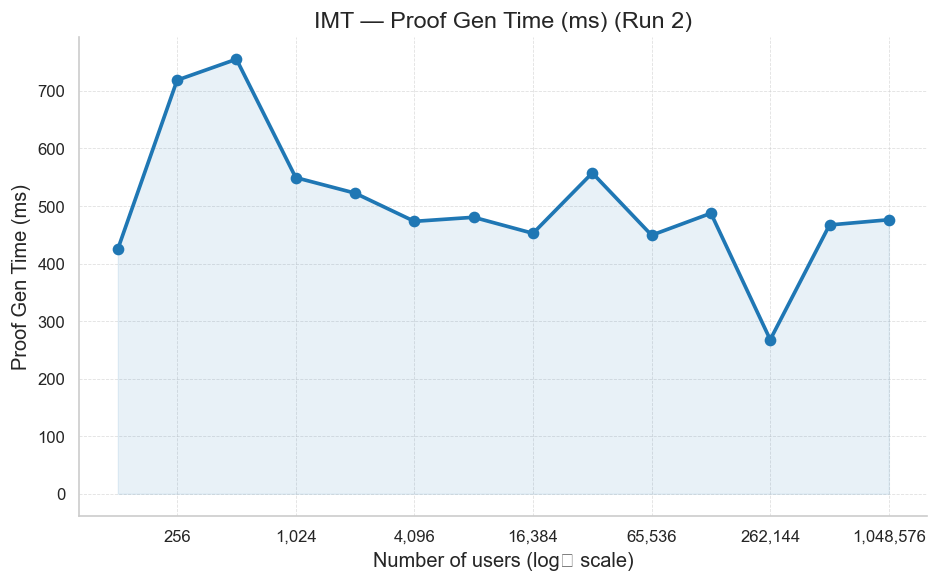

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


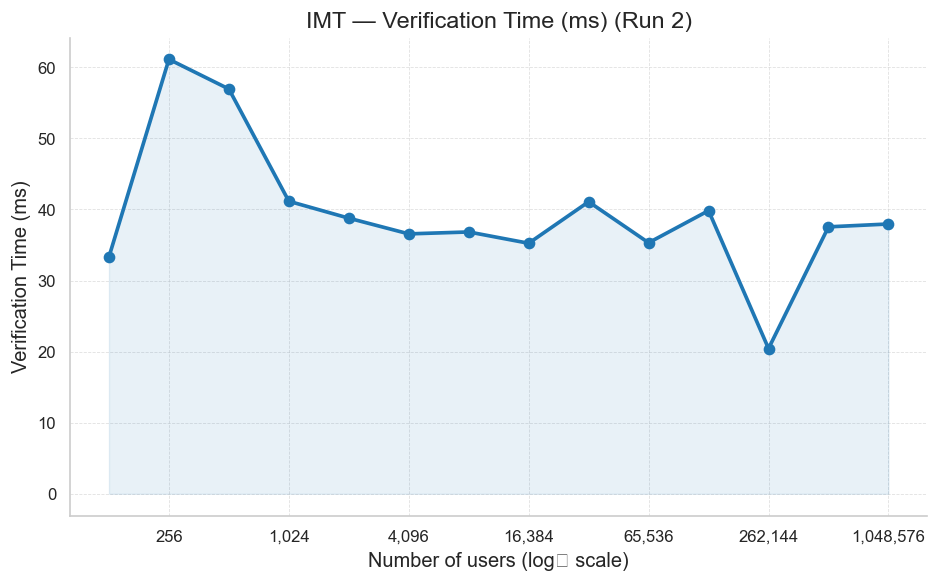

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


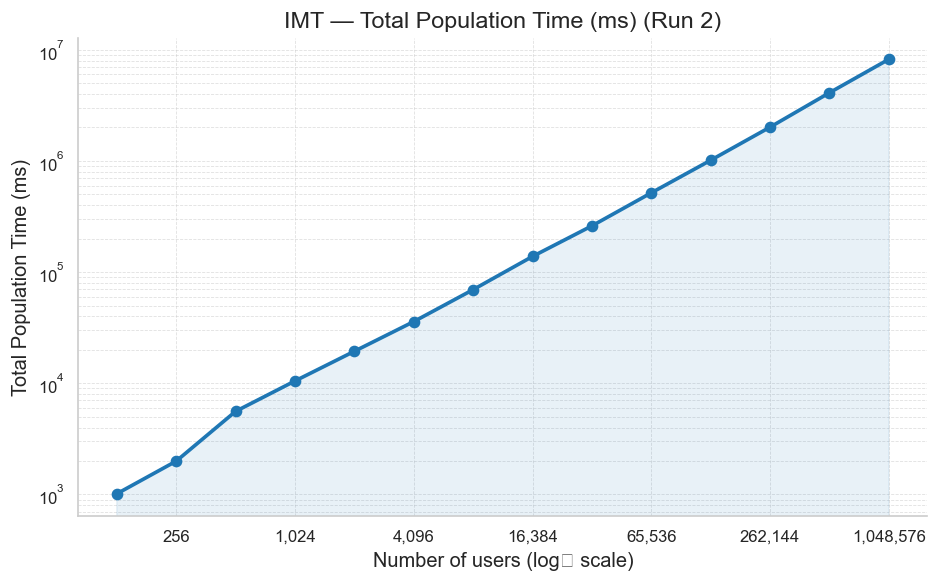

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


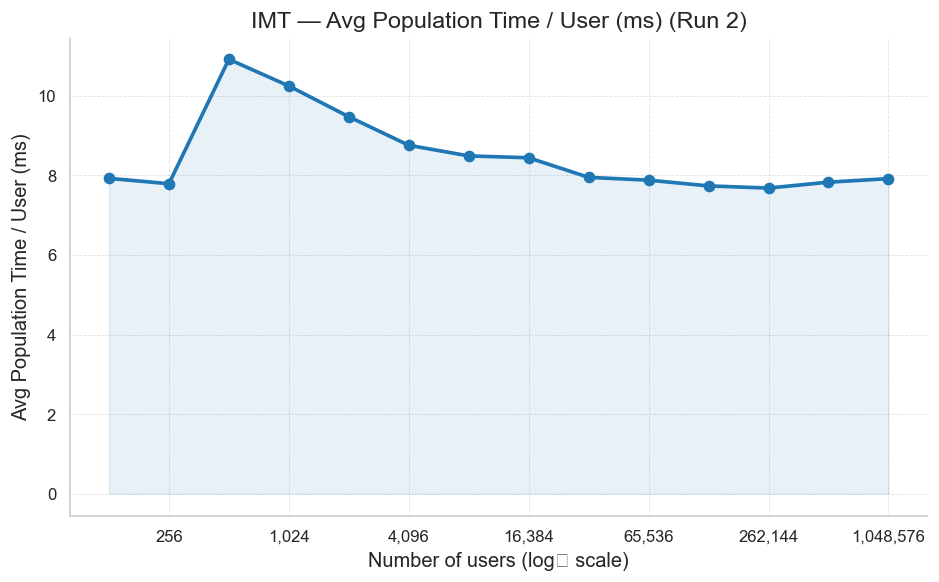

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


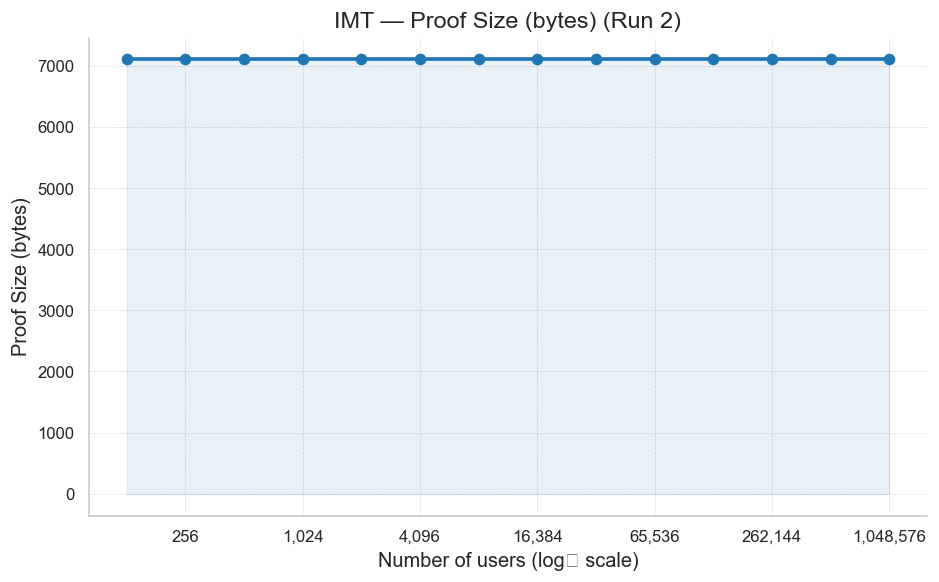

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


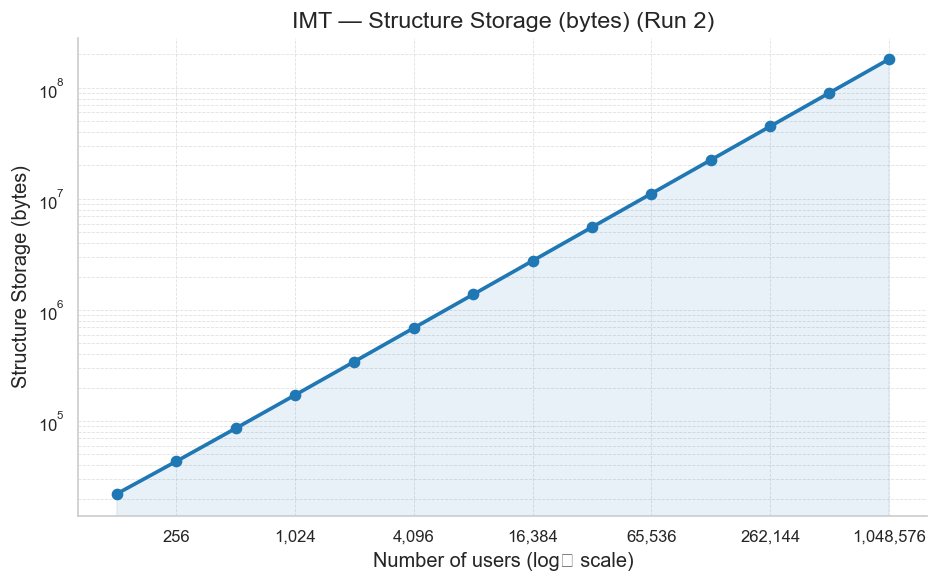


  Polynomial


C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


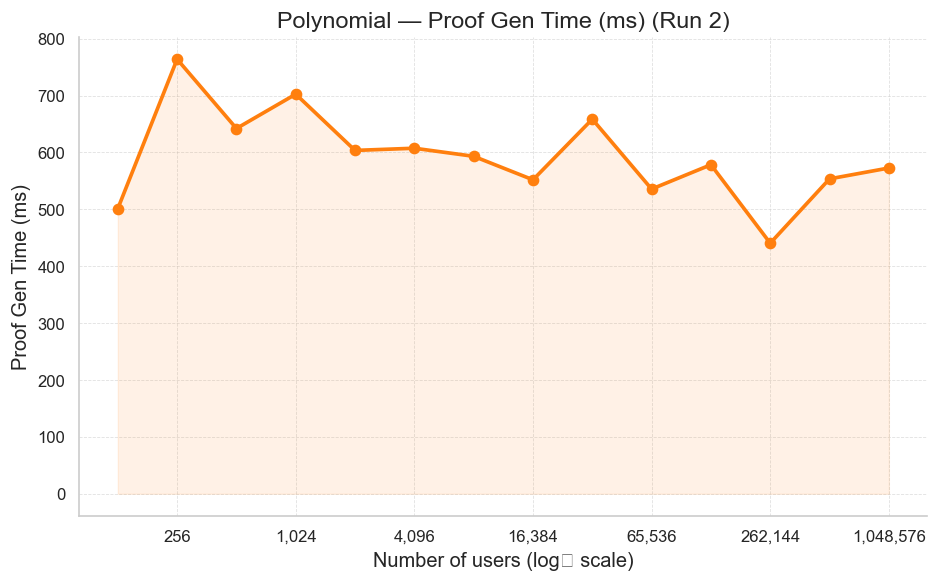

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


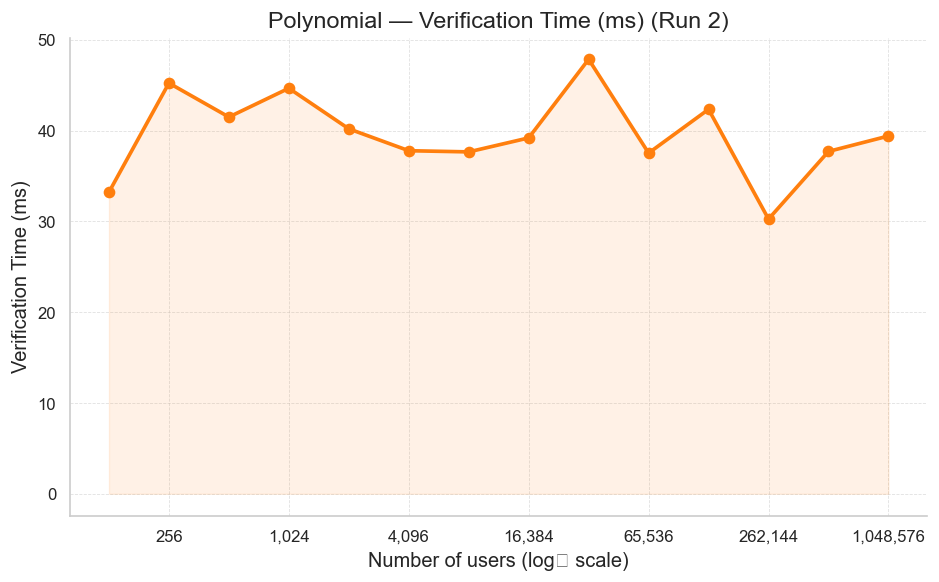

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


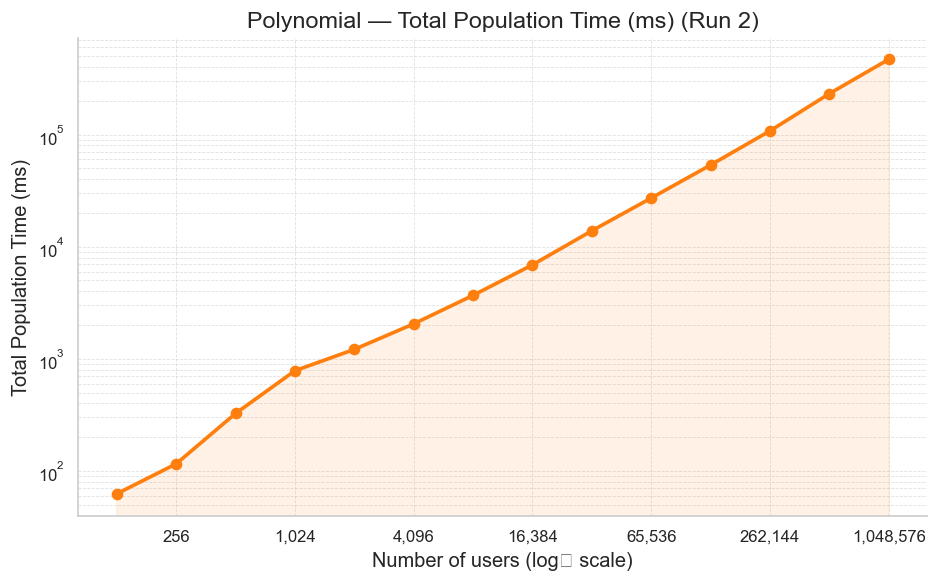

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


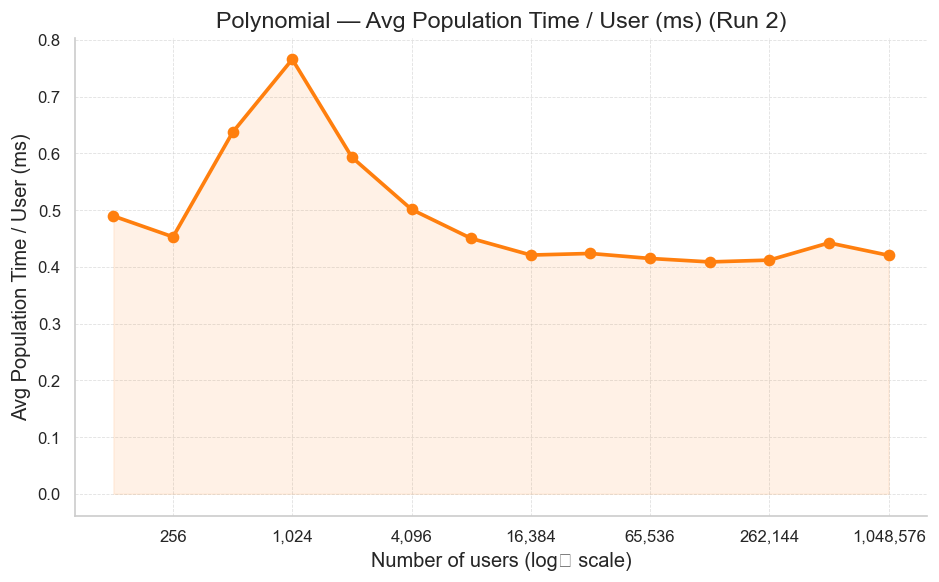

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


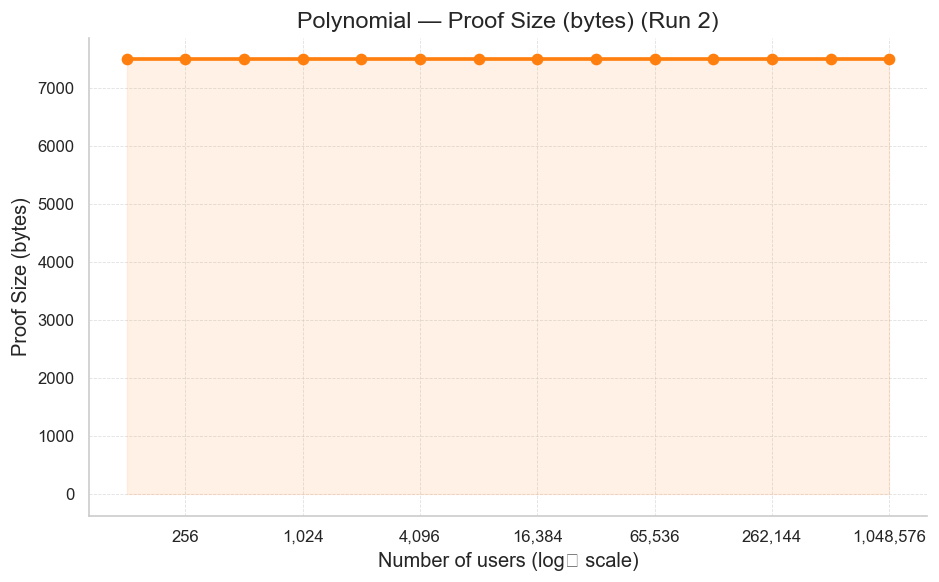

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2258221626.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


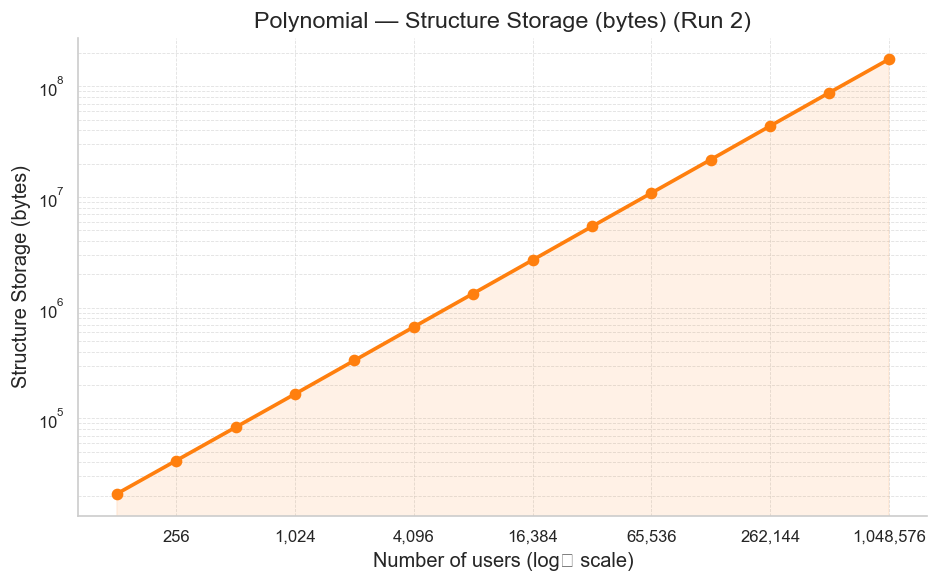

In [48]:
ALL_METRICS = [
    ("proof_gen_time_ms",              "Proof Gen Time (ms)",             False),
    ("verification_time_ms",           "Verification Time (ms)",          False),
    ("total_population_time_ms",       "Total Population Time (ms)",      True),
    ("avg_population_time_ms",         "Avg Population Time / User (ms)", False),
    ("proof_size_bytes",               "Proof Size (bytes)",              False),
    ("total_structure_storage_bytes",  "Structure Storage (bytes)",       True),
]

def plot_single_scheme(df, scheme, run_id, col, ylabel, logy=False):
    data = df[(df['scheme_type'] == scheme) & (df['run_id'] == run_id)].sort_values('user_count')
    fig, ax = plt.subplots(figsize=(8, 5))
    color = SCHEME_COLORS[scheme]
    ax.plot(data['user_count'], data[col],
            color=color, marker='o', linewidth=2.2, markersize=6)
    ax.fill_between(data['user_count'], data[col], alpha=0.1, color=color)
    ax.set_xscale('log', base=2)
    if logy:
        ax.set_yscale('log')
    ax.set_xlabel("Number of users (log₂ scale)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{scheme} — {ylabel} (Run {run_id})")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.tight_layout()
    fig.savefig(GRAPHS_DIR / f"run_{run_id}_{scheme.lower()}_{col}.png", bbox_inches='tight')
    plt.show()
    plt.close(fig)

    plt.show()
    plt.close(fig)

for r in range(1, num_runs + 1):
    print(f"\n{'='*60}")
    print(f"  Individual scheme plots — Run {r}")
    print(f"{'='*60}")
    for scheme in ['IMT', 'Polynomial']:
        print(f"\n  {scheme}")
        for col, ylabel, logy in ALL_METRICS:
            plot_single_scheme(combined, scheme, r, col, ylabel, logy)

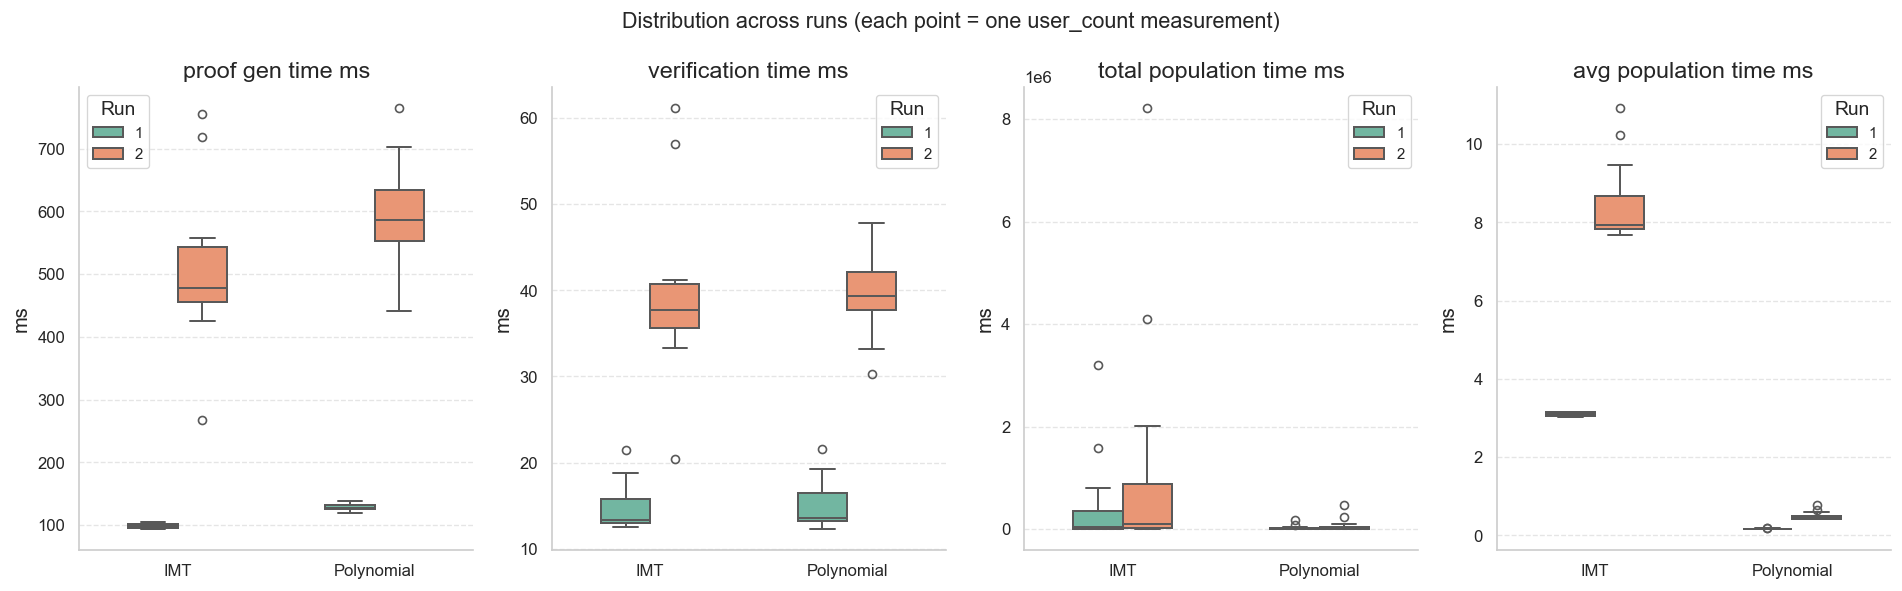

In [49]:
TIME_METRICS = [
    "proof_gen_time_ms",
    "verification_time_ms",
    "total_population_time_ms",
    "avg_population_time_ms",
]

fig, axes = plt.subplots(1, len(TIME_METRICS), figsize=(16, 5), sharey=False)
fig.suptitle("Distribution across runs (each point = one user_count measurement)", fontsize=13)

for ax, col in zip(axes, TIME_METRICS):
    sns.boxplot(
        data=combined,
        x='scheme_type',
        y=col,
        hue='run_id',
        palette='Set2',
        width=0.5,
        linewidth=1.2,
        ax=ax,
    )
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel("")
    ax.set_ylabel("ms")
    ax.legend(title="Run", fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(GRAPHS_DIR / "cross_run_variance.png", bbox_inches='tight')
plt.show()

In [50]:
constant_metrics = [
    "proof_gen_time_ms",
    "verification_time_ms",
    "avg_population_time_ms",
    "proof_size_bytes",
]

peak_metrics = [
    "total_population_time_ms",
    "total_structure_storage_bytes",
]

max_n = combined['user_count'].max()

# Mean across all user counts — valid for constant-per-n metrics
summary_constant = (
    combined.groupby(['scheme_type', 'run_id'])[constant_metrics]
    .mean()
    .reset_index()
)

# Value at max n only — valid for cumulative scaling metrics
summary_peak = (
    combined[combined['user_count'] == max_n]
    .groupby(['scheme_type', 'run_id'])[peak_metrics]
    .first()
    .reset_index()
)

summary = summary_constant.merge(summary_peak, on=['scheme_type', 'run_id'])
summary.columns = ['Scheme', 'Run'] + constant_metrics + peak_metrics

print(f"Mean values (constant metrics) + peak values at n={max_n:,} (scaling metrics):")
display(summary.round(3))

Mean values (constant metrics) + peak values at n=1,048,576 (scaling metrics):


,Scheme,Run,proof_gen_time_ms,verification_time_ms,avg_population_time_ms,proof_size_bytes,total_population_time_ms,total_structure_storage_bytes
0,IMT,1,98.585,14.716,3.100,7104.0,3209287.90,180807035
1,IMT,2,505.902,39.435,8.499,7104.0,8205361.05,180807718
2,Polynomial,1,128.139,14.852,0.171,7488.0,175917.35,176057578
3,Polynomial,2,593.260,39.615,0.488,7488.0,468978.13,175641849


In [51]:
def line_plot_run(df, y, ylabel, title, run_id, logy=False):
    plt.figure(figsize=(8.5, 5.5))

    sns.lineplot(
        data=df[df['run_id'] == run_id],
        x="user_count",
        y=y,
        hue="scheme_type",
        marker="o",
        linewidth=2.5,
        markersize=7,
        palette=["#1f77b4", "#ff7f0e"]
    )

    plt.xlabel("Number of Users (log scale)")
    plt.ylabel(ylabel)
    plt.title(f"{title} (Run {run_id})", pad=12)

    plt.xscale("log", base=2)
    if logy:
        plt.yscale("log")

    plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
    plt.legend(title="Scheme", frameon=True)
    plt.tight_layout()
    plt.savefig(GRAPHS_DIR / f"line_plot_{metric}_run{run_id}.png")
    plt.show()


==================================================  RUN 1  ==================================================


,IMT,Poly,P / I,I / P,Δ% (Poly),Winner
Metric,,,,,,
Proof Gen Time,98.585000,128.139000,1.300×,0.769×,-29.98%,IMT
Verification Time,14.716000,14.852000,1.009×,0.991×,-0.92%,IMT
Avg Population Time,3.100000,0.171000,0.055×,18.127×,+94.48%,Polynomial
Proof Size,7104.000000,7488.000000,1.054×,0.949×,-5.41%,IMT
Total Population Time,3209287.900000,175917.350000,0.055×,18.243×,+94.52%,Polynomial
Total Structure Storage,180807035.000000,176057578.000000,0.974×,1.027×,+2.63%,Polynomial


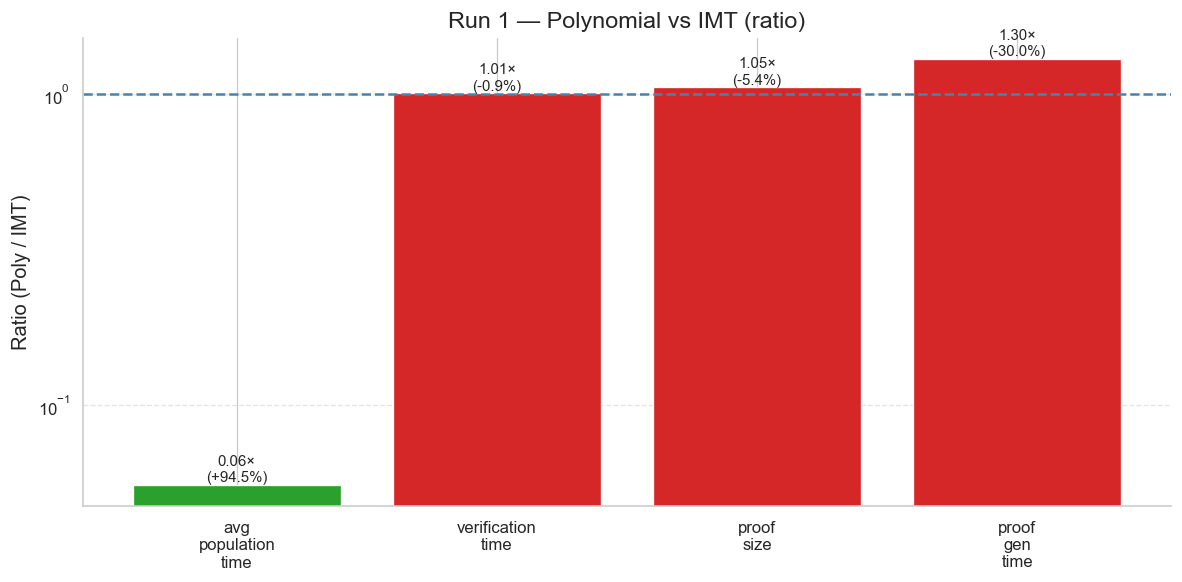


==================================================  RUN 2  ==================================================


,IMT,Poly,P / I,I / P,Δ% (Poly),Winner
Metric,,,,,,
Proof Gen Time,505.902000,593.260000,1.173×,0.853×,-17.27%,IMT
Verification Time,39.435000,39.615000,1.005×,0.995×,-0.46%,IMT
Avg Population Time,8.499000,0.488000,0.057×,17.418×,+94.26%,Polynomial
Proof Size,7104.000000,7488.000000,1.054×,0.949×,-5.41%,IMT
Total Population Time,8205361.050000,468978.130000,0.057×,17.496×,+94.28%,Polynomial
Total Structure Storage,180807718.000000,175641849.000000,0.971×,1.029×,+2.86%,Polynomial


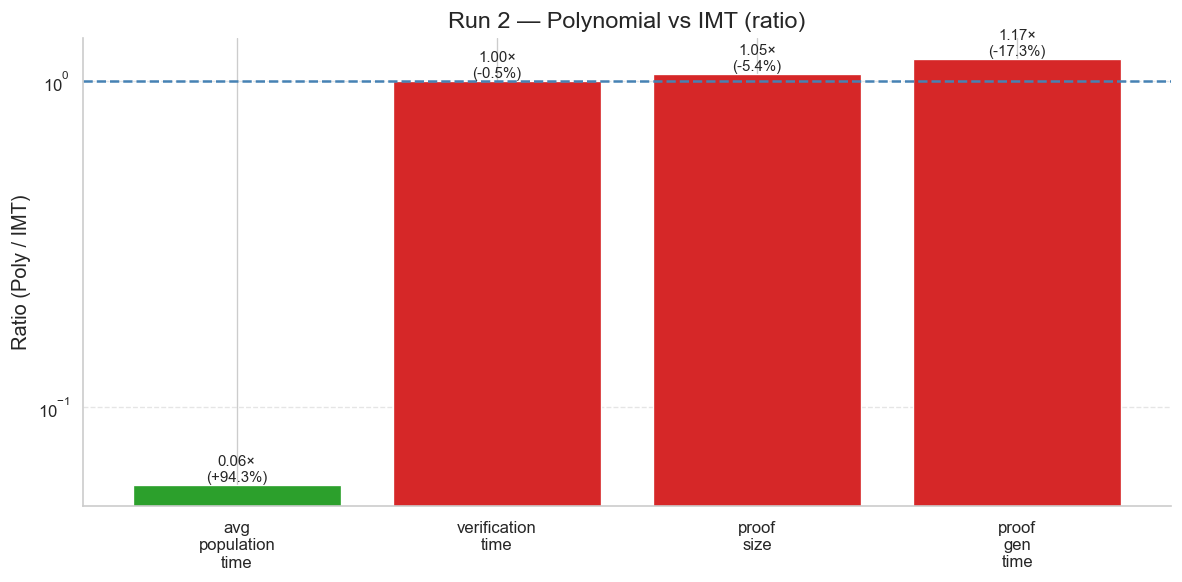

In [52]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt


def ratio_analysis(df, run_id, TITLE_FONT=14):
    run_data = df[df['run_id'] == run_id]
    max_n = run_data['user_count'].max()
    eps = 1e-9

    # ── Constant metrics (mean + std) ────────────────────────────────────────
    stats_constant = run_data.groupby('scheme_type')[constant_metrics].agg(['mean', 'std'])

    # ── Peak metrics at max user count ───────────────────────────────────────
    stats_peak = (
        run_data[run_data['user_count'] == max_n]
        .groupby('scheme_type')[peak_metrics]
        .agg(['mean', 'std'])
    )

    # Flatten columns
    stats_constant.columns = ['_'.join(col) for col in stats_constant.columns]
    stats_peak.columns = ['_'.join(col) for col in stats_peak.columns]

    stats = pd.concat([stats_constant, stats_peak], axis=1)

    # ── Extract means ────────────────────────────────────────────────────────
    all_metrics = constant_metrics + peak_metrics

    imt_vals = []
    poly_vals = []

    for m in all_metrics:
        imt_vals.append(stats.loc['IMT'].get(f"{m}_mean", float('nan')))
        poly_vals.append(stats.loc['Polynomial'].get(f"{m}_mean", float('nan')))

    ratio = pd.DataFrame({
        'Metric': all_metrics,
        'IMT': imt_vals,
        'Polynomial': poly_vals,
    })

    # ── Ratios ───────────────────────────────────────────────────────────────
    ratio['Poly / IMT'] = ratio['Polynomial'] / (ratio['IMT'] + eps)
    ratio['IMT / Poly'] = ratio['IMT'] / (ratio['Polynomial'] + eps)
    ratio['Improvement % (Poly better)'] = (1 - ratio['Poly / IMT']) * 100

    ratio['Winner'] = ratio['Poly / IMT'].apply(
        lambda x: 'Polynomial' if x < 1 else 'IMT'
    )

    # ── Clean Table for Display ──────────────────────────────────────────────
    table = ratio.set_index('Metric').round(3)

    table = table.rename(columns={
        'Polynomial': 'Poly',
        'Poly / IMT': 'P / I',
        'IMT / Poly': 'I / P',
        'Improvement % (Poly better)': 'Δ% (Poly)'
    })

    table.index = (
        table.index
        .str.replace('_ms', '', regex=False)
        .str.replace('_bytes', '', regex=False)
        .str.replace('_', ' ', regex=False)
        .str.title()
    )

    print(f"\n{'='*50}  RUN {run_id}  {'='*50}")

    display(
        table.style
        .set_properties(**{
            'white-space': 'nowrap',
            'text-align': 'center'
        })
        .format({
            'P / I': "{:.3f}×",
            'I / P': "{:.3f}×",
            'Δ% (Poly)': "{:+.2f}%"
        })
    )

    # ── Visualization ────────────────────────────────────────────────────────
    chart = ratio[ratio['Metric'].isin(constant_metrics)].copy()
    chart = chart.sort_values('Poly / IMT')

    labels = [
        m.replace('_ms', '').replace('_bytes', '').replace('_', '\n')
        for m in chart['Metric']
    ]

    values = chart['Poly / IMT'].values
    colors = ['#2ca02c' if r < 1 else '#d62728' for r in values]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=0.8)

    ax.axhline(1.0, color='steelblue', linestyle='--', linewidth=1.5)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.2f}×\n({(1 - val) * 100:+.1f}%)",
            ha='center', va='bottom', fontsize=9
        )

    ax.set_title(f"Run {run_id} — Polynomial vs IMT (ratio)", fontsize=TITLE_FONT)
    ax.set_ylabel("Ratio (Poly / IMT)", fontsize=LABEL_FONT)

    if len(values) > 0 and min(values) > 0 and max(values) / min(values) > 5:
        ax.set_yscale('log')

    ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    fig.savefig(GRAPHS_DIR / f"ratio_run_{run_id}.png", dpi=300)
    plt.show()
    plt.close(fig)


# ── Run for all runs ─────────────────────────────────────────────────────────
for r in range(1, num_runs + 1):
    ratio_analysis(combined, r)

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\1055029847.py:30: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\1055029847.py:31: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(GRAPHS_DIR / "all_runs_scalability.png", bbox_inches='tight')
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


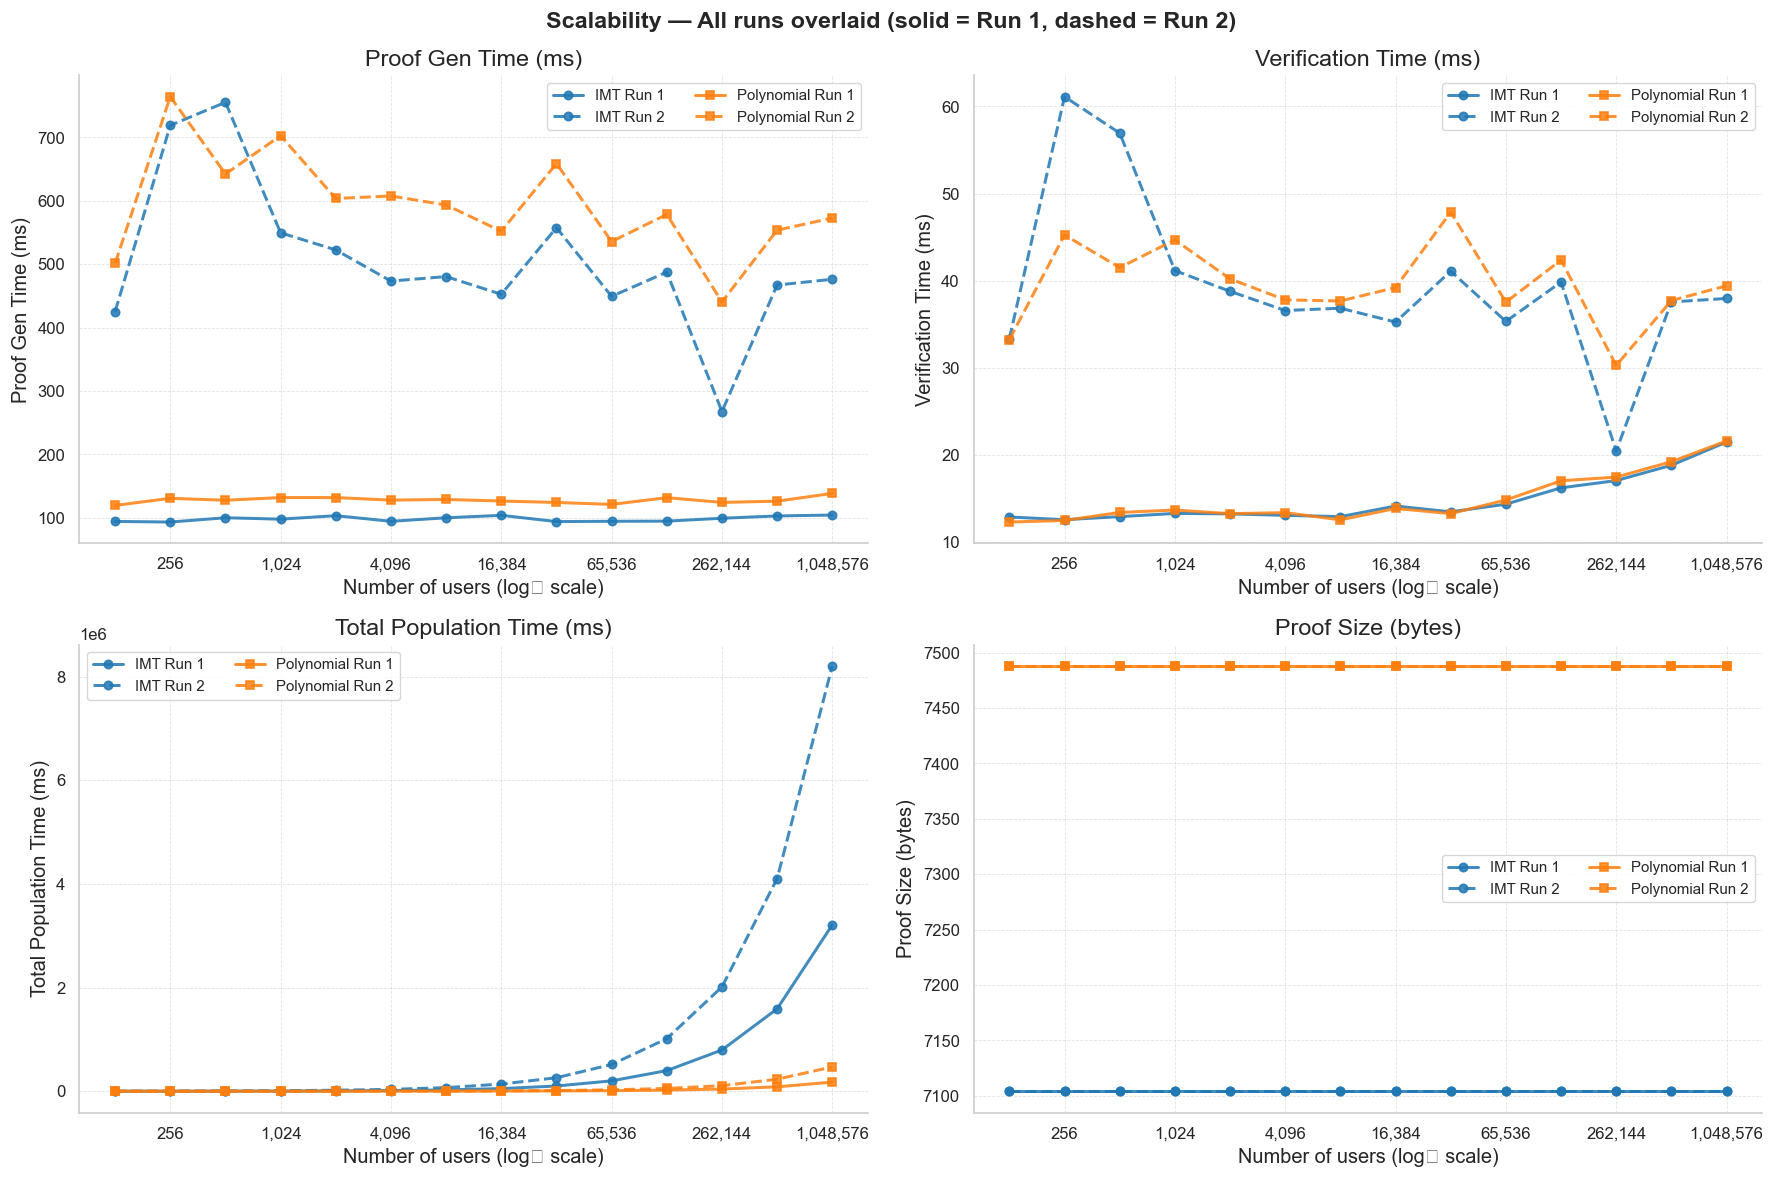

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Scalability — All runs overlaid (solid = Run 1, dashed = Run 2)", fontsize=14, fontweight='bold')

RUN_STYLES = {1: '-', 2: '--'}

for ax, (col, ylabel) in zip(axes.flat, METRICS):
    for scheme in ['IMT', 'Polynomial']:
        for run_id in range(1, num_runs + 1):
            data = combined[(combined['scheme_type'] == scheme) & (combined['run_id'] == run_id)].sort_values('user_count')
            ax.plot(
                data['user_count'],
                data[col],
                linestyle=RUN_STYLES.get(run_id, ':'),
                color=SCHEME_COLORS[scheme],
                marker=SCHEME_MARKERS[scheme],
                markersize=5,
                linewidth=1.8,
                alpha=0.85,
                label=f"{scheme} Run {run_id}",
            )

    ax.set_xscale('log', base=2)
    ax.set_xlabel("Number of users (log₂ scale)")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=9, ncol=2)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.55)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig(GRAPHS_DIR / "all_runs_scalability.png", bbox_inches='tight')
plt.show()

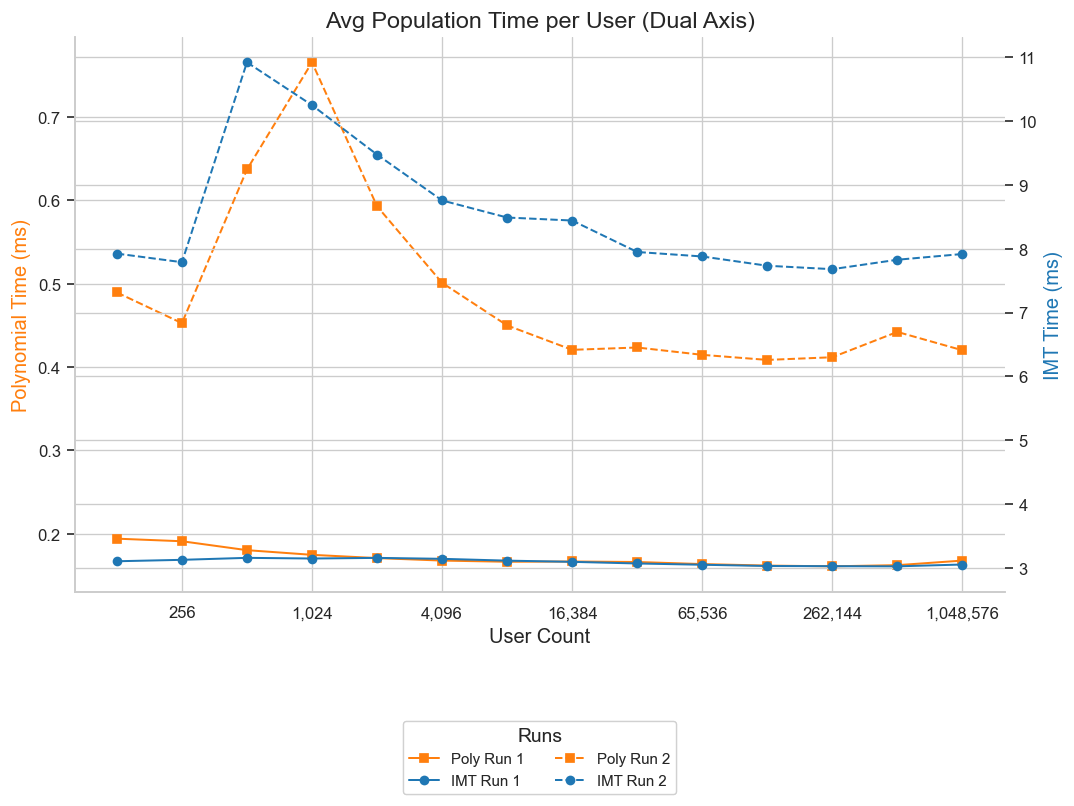

In [54]:
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

# Re-calculating means
poly_avg_mean = combined[combined['scheme_type'] == 'Polynomial']['avg_population_time_ms'].mean()
imt_avg_mean = combined[combined['scheme_type'] == 'IMT']['avg_population_time_ms'].mean()
overall_ratio = imt_avg_mean / poly_avg_mean

fig, ax_pop = plt.subplots(figsize=(10, 6))
ax_imt = ax_pop.twinx()

fmt_x = ticker.FuncFormatter(lambda x, _: f'{int(x):,}')

handles = []
labels = []

for run_id in sorted(combined['run_id'].unique()):
    ls = RUN_STYLES.get(run_id, '-')

    poly = combined[
        (combined['scheme_type'] == 'Polynomial') &
        (combined['run_id'] == run_id)
    ].sort_values('user_count')

    imt = combined[
        (combined['scheme_type'] == 'IMT') &
        (combined['run_id'] == run_id)
    ].sort_values('user_count')

    l1, = ax_pop.plot(
        poly['user_count'], poly['avg_population_time_ms'],
        color=SCHEME_COLORS['Polynomial'], linestyle=ls, marker='s'
    )

    l2, = ax_imt.plot(
        imt['user_count'], imt['avg_population_time_ms'],
        color=SCHEME_COLORS['IMT'], linestyle=ls, marker='o'
    )

    handles.extend([l1, l2])
    labels.extend([f'Poly Run {run_id}', f'IMT Run {run_id}'])

# Axes config
ax_pop.set_xscale('log', base=2)
ax_pop.xaxis.set_major_formatter(fmt_x)

ax_pop.set_ylabel('Polynomial Time (ms)', color=SCHEME_COLORS['Polynomial'])
ax_imt.set_ylabel('IMT Time (ms)', color=SCHEME_COLORS['IMT'])
ax_pop.set_xlabel('User Count')

# ── Legend 1: Runs ───────────────────────────────────────────────
legend1 = ax_pop.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.22),   # slightly lower
    ncol=2,
    fontsize=9,
    frameon=True,
    title="Runs"
)

# Keep the legend
ax_pop.add_artist(legend1)

plt.title('Avg Population Time per User (Dual Axis)')
plt.savefig(GRAPHS_DIR / "avg_population_time_dual_axis.png")
plt.show()

C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2787731071.py:35: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\BS01493\AppData\Local\Temp\ipykernel_27924\2787731071.py:36: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(GRAPHS_DIR / "proof_gen_time.png", bbox_inches='tight', dpi=300)
C:\Users\BS01493\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


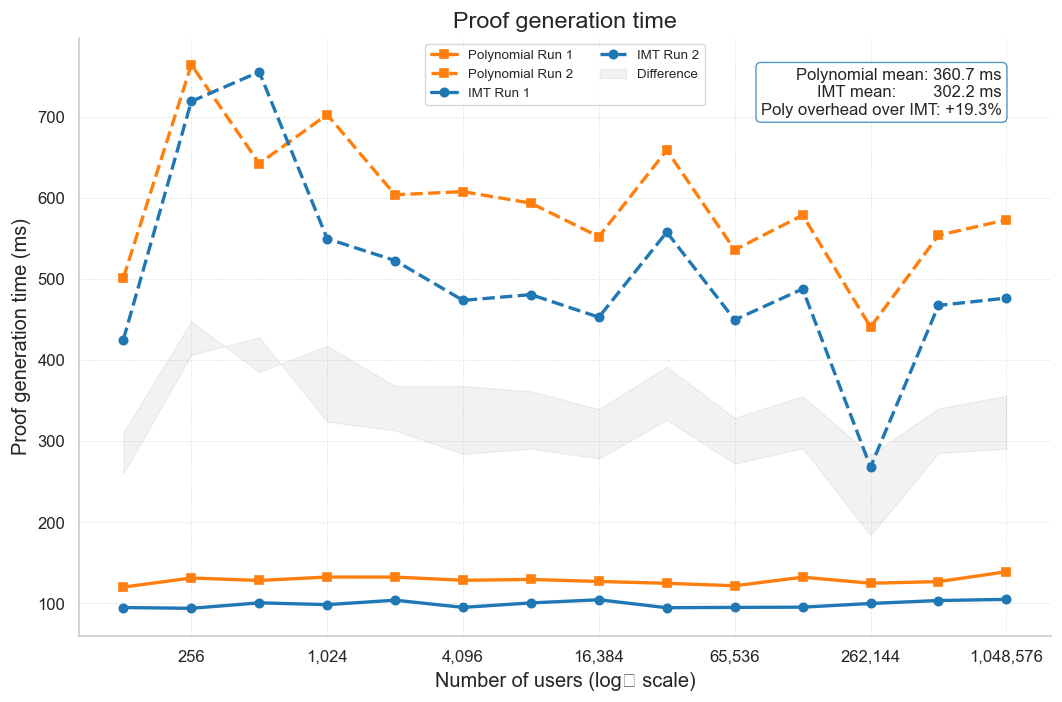

In [55]:
fig, ax_proof = plt.subplots(figsize=(9, 6))

poly_proof_grp = combined[combined['scheme_type'] == 'Polynomial'].groupby('user_count')['proof_gen_time_ms'].mean()
imt_proof_grp = combined[combined['scheme_type'] == 'IMT'].groupby('user_count')['proof_gen_time_ms'].mean()

proof_overhead = (poly_proof_grp.mean() / imt_proof_grp.mean() - 1) * 100

for scheme in ['Polynomial', 'IMT']:
    color = POLY_COLOR if scheme == 'Polynomial' else IMT_COLOR
    mrkr   = POLY_MARKER if scheme == 'Polynomial' else IMT_MARKER
    for run_id, grp in combined[combined['scheme_type'] == scheme].groupby('run_id'):
        grp = grp.sort_values('user_count')
        ax_proof.plot(grp['user_count'], grp['proof_gen_time_ms'],
                      color=color, linestyle=RUN_STYLES[run_id],
                      marker=mrkr, markersize=5, linewidth=2.0,
                      label=f"{scheme} Run {run_id}")

ax_proof.fill_between(poly_proof_grp.index, poly_proof_grp.values, imt_proof_grp.values,
                      alpha=0.10, color='gray', label='Difference')

ax_proof.set_xscale('log', base=2)
ax_proof.set_xlabel("Number of users (log₂ scale)", fontsize=LABEL_FONT)
ax_proof.set_ylabel("Proof generation time (ms)", fontsize=LABEL_FONT)
ax_proof.set_title("Proof generation time", fontsize=TITLE_FONT)
ax_proof.legend(fontsize=8, ncol=2)
ax_proof.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.45)
ax_proof.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_x))

stats_box(ax_proof, [
    f"Polynomial mean: {poly_proof_grp.mean():.1f} ms",
    f"IMT mean:        {imt_proof_grp.mean():.1f} ms",
    f"Poly overhead over IMT: +{proof_overhead:.1f}%",
])

plt.tight_layout()
plt.savefig(GRAPHS_DIR / "proof_gen_time.png", bbox_inches='tight', dpi=300)
plt.show()

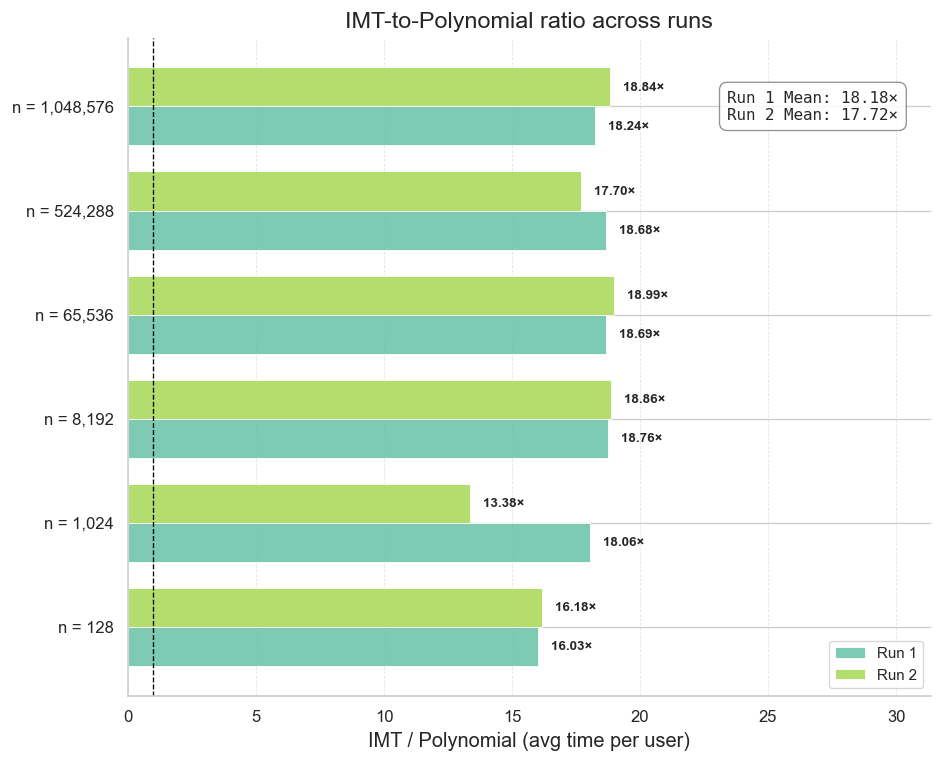

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Helper Function ---
def stats_box(ax, text_lines, loc="upper right", **kwargs):
    """
    Custom wrapper to draw a statistics box inside the plot bounds.
    """
    text_content = "\n".join(text_lines)
    
    if loc == "upper right":
        x, y = 0.96, 0.92  
        va, ha = "top", "right"
    else:
        x, y = 0.96, 0.08
        va, ha = "bottom", "right"
        
    ax.text(
        x, y, text_content,
        transform=ax.transAxes,
        verticalalignment=va,
        horizontalalignment=ha,
        fontsize=9.5,
        fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.85)
    )

# --- 1. Split Data into 14-Row Run Groups ---
imt_df = combined[combined['scheme_type'] == 'IMT'].copy()
poly_df = combined[combined['scheme_type'] == 'Polynomial'].copy()

# Assign run IDs based on 14-row chunks
CHUNK_SIZE = 14
imt_df['run_id'] = np.arange(len(imt_df)) // CHUNK_SIZE
poly_df['run_id'] = np.arange(len(poly_df)) // CHUNK_SIZE

num_runs = imt_df['run_id'].nunique()

# --- 2. Configuration & Layout ---
select_n = [128, 1024, 8192, 65536, 524288, 1048576]
categories = [f"n = {n:,}" for n in select_n]
y_indices = np.arange(len(select_n))

fig, ax_ratio = plt.subplots(figsize=(8, 6.5))

total_group_height = 0.75
bar_height = total_group_height / num_runs
colors = plt.cm.Set2(np.linspace(0, 1, max(num_runs, 3)))

run_stats_lines = []
max_ratio_val = 0

# --- 3. Process & Plot Each Run Group ---
for run_idx in range(num_runs):
    # Isolate current 14-row block
    imt_run = imt_df[imt_df['run_id'] == run_idx].set_index('user_count')['avg_population_time_ms']
    poly_run = poly_df[poly_df['run_id'] == run_idx].set_index('user_count')['avg_population_time_ms']

    # Calculate ratios across all 14 user counts in this run
    run_all_ratios = [imt_run[n] / poly_run[n] for n in imt_run.index if n in poly_run.index]
    run_mean = np.mean(run_all_ratios)
    
    # Track stats line per run
    run_stats_lines.append(f"Run {run_idx + 1} Mean: {run_mean:.2f}×")

    # Sub-select specific n ratios for plotting
    ratios = [imt_run[n] / poly_run[n] for n in select_n]
    max_ratio_val = max(max_ratio_val, max(ratios))

    # Y-offsets for grouped horizontal bars
    offset = (run_idx - (num_runs - 1) / 2) * bar_height
    y_pos = y_indices + offset

    # Plot horizontal bars
    bars = ax_ratio.barh(
        y_pos, ratios,
        height=bar_height,
        label=f"Run {run_idx + 1}",
        color=colors[run_idx],
        alpha=0.85,
        edgecolor='white',
        linewidth=0.6
    )

    # Value labels next to bars
    for bar, val in zip(bars, ratios):
        ax_ratio.text(
            val + 0.5, 
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}×", 
            va='center', 
            fontsize=8, 
            fontweight='bold'
        )

# --- 4. Styling and Axes Setup ---
ax_ratio.set_yticks(y_indices)
ax_ratio.set_yticklabels(categories)
ax_ratio.set_xlabel("IMT / Polynomial (avg time per user)", fontsize=LABEL_FONT)
ax_ratio.set_title("IMT-to-Polynomial ratio across runs", fontsize=TITLE_FONT)
ax_ratio.axvline(1, color='black', linewidth=0.8, linestyle='--')
ax_ratio.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.5)

ax_ratio.set_xlim(0, max_ratio_val * 1.65)
ax_ratio.legend(loc="lower right", fontsize=9)

# --- 5. Statistics Box with Per-Run Means ---
stats_box(
    ax_ratio, 
    run_stats_lines, 
    loc="upper right"
)

plt.tight_layout()
plt.savefig(GRAPHS_DIR / "ratio_bar_chart_grouped.png", bbox_inches='tight', dpi=300)
plt.show()